<div>
<a href="https://www.audiolabs-erlangen.de/fau/professor/mueller"><img src="data_layout/PCPT_Teaser.png" width=100% style="float: right;" alt="PCPT Teaser"></a>
</div>

# Unit 5: Neural Network Modules

<a id=''></a> 

<ul>
    <li><a href='#learn'>Overview and Learning Objectives</a></li>        
    <li><a href='#firstexample'>First Example</a></li>
    <li><a href='#linearmodule'>Linear Module</a></li>
    <li><a href='#classdefinition'>Class Definition of General Neural Networks</a></li>    
    <li><a href='#modeltraining'>Model Training and Optimization</a></li>   
    <li><a href='#secondexample'>Second Example</a></li>
    <li><a href='#furthernotes'>Further Notes</a></li>
    <li><a href='#exercises'>Exercises</a></li>
    <ul>
        <li><a href='#exercise_1'>Exercise 1: </a></li>
        <li><a href='#exercise_2'>Exercise 2: </a></li>    
    </ul>        
</ul>

<a id='learn'></a> 
<div class="alert alert-block alert-warning">
<h2>Overview and Learning Objectives</h2><br>

In this unit, we introduce <code>torch.nn</code> as the core package for deep learning in PyTorch. This package provides essential components that serve as building blocks, similar to neural network layers, facilitating the construction of comprehensive neural network architectures. Moreover, <code>torch.nn</code> extends its utility by providing essential functions, such as loss calculations, optimization techniques, activation functions, and methods for initializing network parameters. Throughout this unit, we will progressively explore the primary features of <code>torch.nn</code>, guiding you through the <strong>creation</strong> and <strong>training</strong> of neural networks step by step, encompassing aspects such as data preparation, model definition, loss functions, forward pass, gradient initialization, backward pass, and optimizers. In particular, we you will gain expertise in defining neural networks by creating <strong>subclasses</strong> of <code>torch.nn</code>, initializing network classes, specifying forward pass operations, and understanding parameter initialization. As we continue to work with our ongoing example from <a href="PCPT_04_grad.html">Unit 4</a>, involving polynomial regression and non-linear function approximation, we will emphasize the practical implementation of the entire pipeline using illustrative small-scale networks. The exercises will provide opportunities to deepen your comprehension by modifying and testing the code introduced in this unit.
</div> 

<a id='keycomponents'></a> 
## Key Components

The `torch.nn` package provides building blocks for creating neural network, which are often called **modules** in PyTorch terminology. These modules are roughly equivalent to neural network layers. Each module receives input tensors and computes output tensors, while keeping track of certain properties and states such as tensors containing learnable parameters. Additionally, `torch.nn` furnishes a diverse set of tools to streamline the creation and training of neural network models. Here is an overview of the key components and features it offers:

* **Modules**: `torch.nn` has a base class called `nn.Module`, which you can use to design your own custom neural networks.  Additionally, it offers ready-made building blocks or layers, including linear (fully connected), convolutional, and recurrent layers.

* **Activation Functions**: It includes commonly used activation functions like ReLU, sigmoid, and tanh.

* **Loss Functions**: You can also find loss functions, which are used to measure how far off your model predictions are from the target values. Common examples include mean squared error (MSE) and cross-entropy.

* **Optimizers**: Within the `torch.nn` package, you also find popular optimization methods like stochastic gradient descent (SGD) and Adam. These optimizers are used to update model parameters during training.

* **Functional Interfaces**: Apart from the object-oriented approach, `torch.nn.functional` offers a functional way to perform many standard operations commonly used in neural networks. It allows for using these operations without creating explicit layer objects.

* **Initialization Methods**: Finally, `torch.nn.init` offers functions for weight initialization, which is crucial for training deep networks effectively.


<div class="alert alert-block alert-warning">In PyTorch, one finds the term <strong><strong>module</strong></strong> to refer to the individual building blocks of a neural network. In deep learning terminology, these building blocks are usually called <strong><strong>layers</strong></strong>. Note that the term <strong><strong>module</strong></strong> in the PyTorch context has <strong><strong>nothing</strong></strong> in common with <a href=https://docs.python.org/3/tutorial/modules.html><strong><strong>Python modules</strong></strong></a>  
</div>

<a id='firstexample'></a> 
## First Example

To give a first impression on how `torch.nn` works, we continue with our polynomial regression example from <a href="PCPT_04_grad.html">Unit 4</a>. Recall that we are given a training pairs provide by an array `x` of input values and an array `y` of target values.  

In [1]:
import os    
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [2]:
import numpy as np
import torch
from torch import nn
import torch.optim as optim
from matplotlib import pyplot as plt

def training_pairs(num=200):
    np.random.seed(seed=0)
    x = np.random.uniform(0,2,num)
    y =  x + 2*(x-0.9)**2 + 0.3*np.cos(20*x) + 0.1*np.random.randn(num)
    return x, y

def plot_result(x_train, y_train, para=None, model=None):
    plt.figure(figsize=(5, 2))
    plt.scatter(x_train, y_train, color='black', marker='.', label='training')
    if para or model:
        x_val = torch.linspace(0, 2, 100).unsqueeze(1)
        if para:
            y_val = para[0] + para[1] * x_val + para[2] * x_val ** 2
        if model:
            y_val = model(x_val).detach()
        plt.plot(x_val, y_val, color='red', linewidth=2.0, linestyle='-', label='validation')
    plt.tight_layout()
    plt.legend(loc='upper left')
        
x_np, y_np = training_pairs()

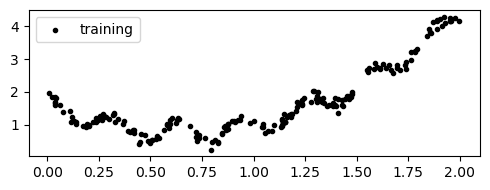

In [3]:
plot_result(x_np,  y_np)    

For this example, we consider the prediction `y_pred` to be a linear function of `x` and `x**2`. Being a polynomial regression of degree two, this problem can be solved with a linear layer neural network. In the following code cell, we provide an implementation for a gradient-based learning approach using the functionality from the `torch.nn` package. The main steps are as follows:

* **Data preparation**: We create tensors to hold input and target values. The input tensor will consists of two dimensions, where the first dimension corresponds to the **batch dimension** of the network (in our case, the number of training pairs) and the second dimension to the number of variables (in our case two, corresponding to `x` and `x**2`).

* **Model**: We use the `torch.nn` package to define our model as a linear model using `torch.nn.Linear`.

* **Loss**: We define the `loss` function using the MSE loss contained in `torch.nn`.

* **Forward pass**: We define the forward pass, which is the output of the model.

* **Gradient initialization**: We set the gradients to zero using `.zero_grad()`.

* **Backward pass**: We compute the gradient via backward tracking using `loss.backward()`.

* **Gradient descent**: We update the weights using gradient descent.

We will go through these steps and the main components in more detail after providing the example code.

Iteration: 500, Loss: 35.051422119140625
Iteration: 1000, Loss: 23.579687118530273
Iteration: 1500, Loss: 17.45853614807129
Iteration: 2000, Loss: 14.192378997802734
Result: a = 1.3355, b = -1.876, c = 1.6554


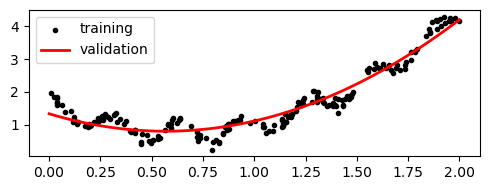

In [4]:
# Data preparation
y = torch.from_numpy(y_np).to(dtype=torch.float32).unsqueeze(1)
x = torch.zeros((len(x_np),2))
x[:,0] = torch.from_numpy(x_np).to(dtype=torch.float32)
x[:,1] = torch.from_numpy(x_np).to(dtype=torch.float32).pow(2)

# Model
torch.manual_seed(0)
model = torch.nn.Linear(2, 1)   

# Loss
loss_fn = torch.nn.MSELoss(reduction='sum')

learning_rate = 1e-4
num_iterations = 2000
for k in range(1, num_iterations+1):
    
    # Forward pass
    y_pred = model(x)
    loss = loss_fn(y_pred, y)
    if k % 500 == 0:
        print(f"Iteration: {k}, Loss: {loss}", flush=True)   
        
    # Gradient initialization     
    model.zero_grad()
    
    # Backward pass
    loss.backward()
    
    # Gradient descent
    with torch.no_grad():
        for param in model.parameters():
            param -= learning_rate * param.grad
    
# For a linear layer, its parameters are stored as `weight` and `bias`
linear_layer = model
a = linear_layer.bias.item()
b = linear_layer.weight[:, 0].item()
c = linear_layer.weight[:, 1].item()
    
print(f'Result: a = {a:6.4f}, b = {b:6.4}, c = {c:6.4f}')
plot_result(x_np,  y_np, para=[a,b,c]) 

<a id='linearmodule'></a> 
## Linear Module

Let us dive deeper into the main components of the above pipeline, starting with how the model is defined. The `torch.nn.Linear` class defines a linear layer, also known as **fully connected** or **dense** layer. A linear layer carries out an affine transformation of its input data, which can be expressed as `output = input x weight + bias`. In this equation:

* `input` usually encodes a matrix (or tensor), where each row represents a different data point (or a higher-dimensional tensor, where the first dimension typically encodes the batch).
* `weight` denotes a weight matrix (or higher-dimensional tensor) that determines how the input data undergoes a linear transformation. 
* `bias` is an optional vector added to the output. It helps the model account for offsets or shifts in the data. 

Both the weights and biases are learned during training. In PyTorch, one can create a linear layer using the `torch.nn.Linear` class, specifying the input and output dimensions as parameters. For example, [`torch.nn.Linear(N, M, bias=True)`](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) defines a layer where: 

* The input has the shape  `(*, N)`, where `∗` can represent any number of dimensions, including `None`, and `N` stands for the number of input features.
* The output has the shape `(*, M)`, where `*` represents the same dimension as `*` in the input, and `M` stands for number of output features.

The learnable parameters are the weight matrix of size `N x M` and the bias vector of size `M`. The initialization of these parameters is automatically handled using a random number generator with a preset distribution. Note that in this specification, the `*` is used to indicate that there can be any number of dimensions or axes before the specified input and output dimensions. For example, the shape of the input tensor could be `(batch_size, N)`, and the shape of the output tensor could be `(batch_size, M)`. In such a scenario, the `*` allows for handling different batch sizes.

In our previous example, we used a  `torch.nn.Linear(2, 1)` module, which was applied to the input matrix `x`. In this case, the `*` corresponds to the number of training pairs, while the input dimension is `N=2` and the output dimension `M=1`.

In [5]:
print("Shape of input tensor:", {x.shape})
print("Shape of output tensor:", {y_pred.shape})
print("Linear layer:", model)
print("Weight:", model.weight)
print("Bias:", model.bias)

Shape of input tensor: {torch.Size([200, 2])}
Shape of output tensor: {torch.Size([200, 1])}
Linear layer: Linear(in_features=2, out_features=1, bias=True)
Weight: Parameter containing:
tensor([[-1.8764,  1.6554]], requires_grad=True)
Bias: Parameter containing:
tensor([1.3355], requires_grad=True)


<a id='classdefinition'></a> 
## Class Definition of General Neural Networks

At this point, we assume that you are familiar with the concept of [Python Classes](https://docs.python.org/3/tutorial/classes.html) as reviewed in [Unit 2](PCPT_02_classes.html) of this PCPT course. The `torch.nn.Linear` is a special case (a **child class**) of the class `tourch.nn.Module`, which is the **parent class** (or base class) for all neural network modules one can create in PyTorch. To define a general neural network in PyTorch, one needs to define a child class of `tourch.nn.Module`, initialize the neural network layers in `__init__()`, and define the operations on the input data in the `forward` method. 

Let us have a look at a concrete example defining a network called `NN_linear`. To use the network, one needs to create an instance of `NN_linear`. Calling the model `model`, its structure can then be printed using `print(model)`.

In [6]:
class NN_linear(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_model = nn.Linear(2, 1)

    def forward(self, x):
        y = self.linear_model(x)
        return y
    
model = NN_linear()
print(model)

NN_linear(
  (linear_model): Linear(in_features=2, out_features=1, bias=True)
)


The class `nn.Module` automatically tracks all fields defined inside the model object, and makes all parameters accessible via the methods `parameters()` or `named_parameters()`. One can explore the model as follows:

* The layers as outputted by `print(model)` are specified by `model._modules` as `OrderedDict`.
* The method `model.parameters()` returns an iterator over all the **learnable parameters** of the model. 
* The method `model.named_parameters()` returns an iterator, yielding both the name of the parameter as well as the parameter itself.
* The method `numel()` returns the total number of elements in the input tensor. 

In [7]:
print(model._modules)

for name, para in model.named_parameters():
    print(f"Name: {name}; Shape: {para.shape}; Number: {para.numel()}")
          
total = sum(para.numel() for para in model.parameters())
print(f"Total number of parameters: {total}")

OrderedDict({'linear_model': Linear(in_features=2, out_features=1, bias=True)})
Name: linear_model.weight; Shape: torch.Size([1, 2]); Number: 2
Name: linear_model.bias; Shape: torch.Size([1]); Number: 1
Total number of parameters: 3


Here some further notes that may help to better understand the definition of the `NN_linear` class.

* `__init__(self)` is a special method within a Python class that serves as the constructor. It is automatically called when an instance of the class is created. 

* `super().__init__()` is used to call the constructor of the parent class. It is typically used within the `__init__` method of a subclass to ensure that the initialization of the parent class is executed before any additional initialization specific to the subclass.

* Within the `__init__` method, one needs to define the layers and modules (in particular, those with trainable parameters) that make up your neural network. In our example, we only specified a single linear module `nn.Linear(2, 1)` with the instance attribute name `.linear_model`.

* The `forward` method in a network class defines how data flows through the neural network during the forward pass. It specifies the operations and transformations applied to the input data to produce the output. In our example, we only have one layer that describes the input&ndash;output behavior of `NN_linear`.

* The network parameters are **initialized** automatically using a default method. The default method depends on the layer and parameter types and typically involves some randomization. For example, in the case of our linear layer, the weights are initialized according to some uniform distribution of a suitably defined range, see [here](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html#torch.nn.Linear) for details.

In the following code cell, we output the all parameters of `NN_linear`. Note that the parameters are specified as PyTorch tensors with `requires_grad=True` used as default. 

In [8]:
for name, para in model.named_parameters():
    print(f"Name: {name}; Parameters: {para}")    

Name: linear_model.weight; Parameters: Parameter containing:
tensor([[-0.5204, -0.2723]], requires_grad=True)
Name: linear_model.bias; Parameters: Parameter containing:
tensor([0.1896], requires_grad=True)


<a id='modeltraining'></a> 
## Model Training and Optimization

After gaining an initial insight into the construction of neural networks, we now turn to optimizing the network parameters. Optimization in PyTorch is a fundamental aspect of training machine learning models. It involves the process of finding the optimal set of parameters (weights and biases) for a given model that minimizes a certain loss function. Recall our general pipeline where we first define a **neural network model** and specified a **loss function** that measures the error between the model's predictions and the target values. We then use **gradient descent** to minimize this error by suitably modifying the network parameters. 

In general, the optimization of neural networks using gradient descent is challenging due to several reasons (e.g., high-dimensional parameter spaces, non-convex loss surfaces, vanishing and exploding gradients). In this context, the [`torch.optim` module](https://pytorch.org/docs/stable/optim.html) in PyTorch offers provides a wide range of optimization algorithms commonly used in deep learning and machine learning tasks. The most commonly used optimization algorithm in PyTorch is **stochastic gradient descent** (SGD), but PyTorch also supports various other optimization algorithms such as Adam, RMSprop, and more. 

<span style="color: red;">In [Unit ???](), we will delve deeper into the facets of optimization and convergence issues. </span> For the moment, we discuss the key concepts that form the core of most training approaches in deep learning. First, one needs to specify a **model** `model` and a **loss function** `loss_fn`. Second, one need to **construct an optimizer** using `torch.optim`, which requires the following:

* A choice of an optimization algorithm (e.g., SGD) 
* The specification of the learnable model parameters given by `model.parameters()`
* The specification of further parameters (e.g., the learning rate `lr`). 

In our example, we will use `optim.SGD(model.parameters(), lr=1e-4)`. Then the **training loop** can start, where one iterates through the training data (typically in batches or mini-batches). This loop includes the following steps:

*  **Forward pass** to obtain predictions from the input.
* **Loss computation** to get the error between predictions and targets.
* **Gradient reset** using `optimizer.zero_grad()` (since gradients are accumulated in PyTorch backtracking)
* **Backpropagation** using `loss.backward()` to compute the gradient. 
* **Parameter update** based on gradient descent using `optimizer.step()`

Note that calling the method `optimizer.zero_grad()` is a convenient way to reset the gradients of all the parameters in the model that the optimizer is responsible for optimizing. Furthermore, the method `optimizer.step()` automatically updates the model parameters based on the gradients computed during backpropagation. 

In the following code cell, we implement this iterative training approach defining the function `training_loop` and apply it to our running example.

<span style="color: red;">Does one need <code>torch.no_grad()</code> for <code>optimizer.step()</code>? </span> 





Iteration: 500, Loss: 35.051422119140625
Iteration: 1000, Loss: 23.579687118530273
Iteration: 1500, Loss: 17.45853614807129
Iteration: 2000, Loss: 14.192378997802734
Result: a = 1.3355, b = -1.876, c = 1.6554


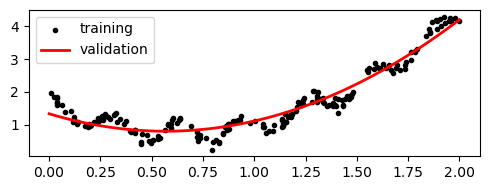

In [9]:
def training_loop(n_epochs, optimizer, model, loss_fn, x_train, y_train):
    for k in range(1, n_epochs + 1):        
        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)            
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if k % 500 == 0:
            print(f"Iteration: {k}, Loss: {loss}", flush=True)

# Data preparation
x_np, y_np = training_pairs()
y = torch.from_numpy(y_np).to(dtype=torch.float32).unsqueeze(1)
x = torch.zeros((len(x_np),2))
x[:,0] = torch.from_numpy(x_np).to(dtype=torch.float32)
x[:,1] = torch.from_numpy(x_np).to(dtype=torch.float32).pow(2)

torch.manual_seed(0)
model = NN_linear()
optimizer = optim.SGD(model.parameters(), lr=1e-4) 

training_loop(
    n_epochs = 2000, 
    optimizer = optimizer,
    model = model,
    loss_fn = nn.MSELoss(reduction='sum'),
    x_train = x,
    y_train = y
) 

a = model._modules['linear_model'].bias.item()
b = model._modules['linear_model'].weight[:,0].item()
c = model._modules['linear_model'].weight[:,1].item()  
print(f'Result: a = {a:6.4f}, b = {b:6.4}, c = {c:6.4f}')
plot_result(x_np,  y_np, para=[a,b,c]) 
            

<a id='secondexample'></a> 
## Second Example

To further illustrate the functionality of `torch.nn` package, let us define a slightly more complex neural network. We again use the training data of our running example. However, rather then using polynomial regression as before, we now want to predict the target values `y` only from the input tensor `x` (rather than `x` and `x**2` as before). To account for the non-linear relationship between `x` and `y`, we use a neural network that consists of 

* a first linear layer `nn.Linear(1, 3)`, 
* followed by a non-linear activation `nn.ReLU()`, and
* closing with a second linear layer `nn.Linear(3, 1)`.

Note that the output dimension of the first linear layer (which is `3`) must be equal to the input dimension of the second layer. The enclosed activation function is applied component wise and leaves the dimensions untouched. The following code cells demonstrate how this neural network can be implemented as a child calls `NN` of the parent class `nn.Module`:

In [10]:
class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin1 = nn.Linear(1, 3)
        self.relu = nn.ReLU()
        self.lin2 = nn.Linear(3, 1)    

    def forward(self, x):
        x = self.lin1(x)
        x = self.relu(x)
        y = self.lin2(x)       
        return y     

In the next code cell, we initiate a model, print out its network structure, and compute the total number of learnable parameters. Note that, as mentioned above, these parameters are randomly initialized. Therefore, without training, the model can be directly applied to some input tensor (of dimension `(*,N)` with `N=1`) yielding an output tensor (of dimension `(*,M)` with `M=1`).

In [11]:
torch.manual_seed(0)
model = NN()
print(model)
for name, para in model.named_parameters():
    print(f"Name: {name}; Shape: {para.shape}; Number: {para.numel()}")
total = sum(para.numel() for para in model.parameters())
print(f"Total number of parameters: {total}")    
    
x =  torch.tensor([[0],[1],[2]], dtype=torch.float)
print('Input tensor:\n', x)
y = model(x)
print('output tensor:\n', y)

NN(
  (lin1): Linear(in_features=1, out_features=3, bias=True)
  (relu): ReLU()
  (lin2): Linear(in_features=3, out_features=1, bias=True)
)
Name: lin1.weight; Shape: torch.Size([3, 1]); Number: 3
Name: lin1.bias; Shape: torch.Size([3]); Number: 3
Name: lin2.weight; Shape: torch.Size([1, 3]); Number: 3
Name: lin2.bias; Shape: torch.Size([1]); Number: 1
Total number of parameters: 10
Input tensor:
 tensor([[0.],
        [1.],
        [2.]])
output tensor:
 tensor([[0.1390],
        [0.2220],
        [0.4676]], grad_fn=<AddmmBackward0>)


In the next code cell, we apply this model to our running example and plot the result on a validation set. Note that the combination of two linear layers interleaved with the non-linear `ReLU` activation function allowed the network to learn a piecewise linear function that approximates well the relation between `x` and `y`.

Iteration: 500, Loss: 22.837451934814453
Iteration: 1000, Loss: 15.702129364013672
Iteration: 1500, Loss: 14.527729988098145
Iteration: 2000, Loss: 13.692564964294434


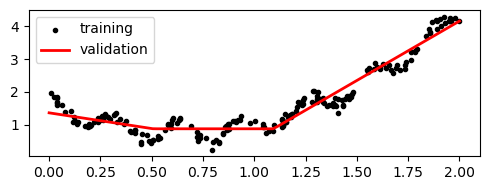

In [12]:
# Data preparation
x_np, y_np = training_pairs()
x = torch.from_numpy(x_np).to(dtype=torch.float32).unsqueeze(1)
y = torch.from_numpy(y_np).to(dtype=torch.float32).unsqueeze(1)

torch.manual_seed(0)
model = NN()

training_loop(
    n_epochs = 2000, 
    optimizer = optim.SGD(model.parameters(), lr=1e-4) ,
    model = model,
    loss_fn = nn.MSELoss(reduction='sum'),
    x_train = x,
    y_train = y
) 

plot_result(x, y, model=model)

<a id='furthernotes'></a> 
## Further Notes



* For further reading, we recommend the unit [Build the Neural Network](https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html), which is part of the tutorial [Introduction to PyTorch](https://pytorch.org/tutorials/beginner/basics/intro.html). 

* In this unit, we have only explored the fully connected layer, `nn.Linear`, and the non-linear activation function, `nn.ReLU()`, as examples of components within `nn.Module`. PyTorch offers a diverse range of additional modules, including `nn.Sequential` (a container module), `nn.Conv2d` (convolutional layer), `nn.RNN,` (recurrent layer), `nn.Dropout` (dropout regularization), `nn.BatchNorm2d` (batch normalization), as well as numerous activation functions. We will encounter some of these modules in later units.  For a comprehensive overview, please refer to the [`torch.nn` documentation](https://pytorch.org/docs/stable/nn.html).

<div>
<a href="https://opensource.org/licenses/MIT"><img src="data_layout/PCPT_License.png" width=100% style="float: right;" alt="PCPT License"></a>
</div>